In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
print("done")


done


In [3]:
X_train = np.linspace(-1, 1, 20)
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])
X_test = np.linspace(-1, 1, 20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])


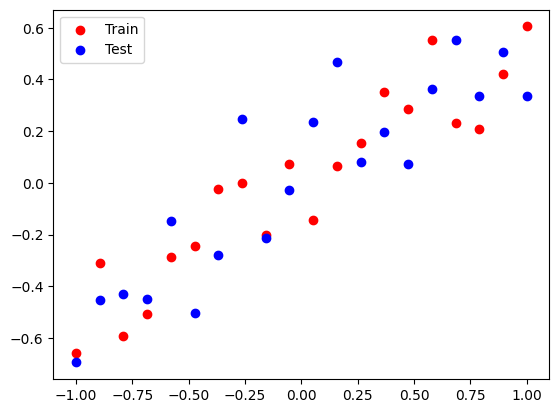

In [4]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

## Regression Model

In [7]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(1,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))
adam=Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='mean_squared_error', metrics=['mean_squared_error'])
history = model.fit(X_train, y_train, epochs=100, batch_size=4, validation_data=(X_test, y_test),verbose=False)

In [8]:
train_mse=model.evaluate(X_train, y_train, verbose=0)
test_mse=model.evaluate(X_test, y_test, verbose=0)
print('Train {:.4f}, Test {:.4f}'.format(train_mse[1], test_mse[1]))

Train 0.0133, Test 0.0335


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


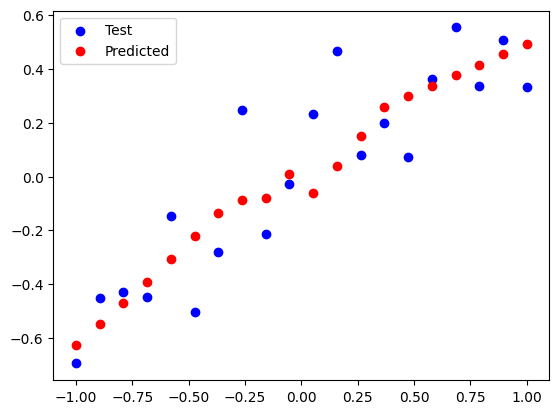

In [10]:
y_pred = model.predict(X_test)
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.scatter(X_test, y_pred, c='red', label='Predicted')
plt.legend()
plt.show()



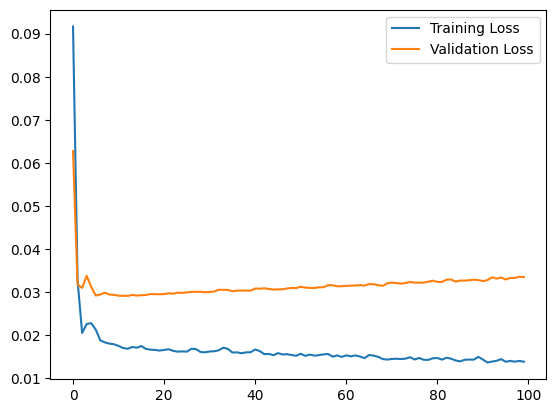

In [13]:
plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

## IMPL DropOut

In [37]:
model_DropOut = Sequential()
model_DropOut.add(Dense(128, activation='relu', input_shape=(1,)))
model_DropOut.add(Dropout(0.2))
model_DropOut.add(Dense(128, activation='relu'))
model_DropOut.add(Dropout(0.7))
model_DropOut.add(Dense(1, activation='linear'))
adam=Adam(learning_rate=0.001)
model_DropOut.compile(optimizer=adam, loss='mean_squared_error', metrics=['mean_squared_error'])
history = model_DropOut.fit(X_train, y_train, epochs=100, batch_size=4, validation_data=(X_test, y_test),verbose=False)
_,test_mse=model_DropOut.evaluate(X_test, y_test, verbose=0)
_,train_mse=model_DropOut.evaluate(X_train, y_train, verbose=0)
print('Train {}, Test {}'.format(train_mse, test_mse))

Train 0.015959933400154114, Test 0.030904080718755722


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


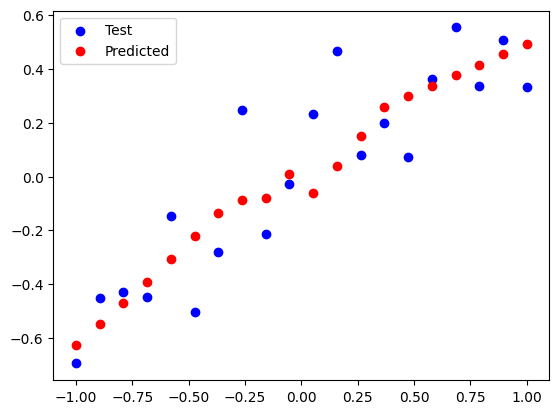

In [38]:
y_pred = model.predict(X_test)
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.scatter(X_test, y_pred, c='red', label='Predicted')
plt.legend()
plt.show()


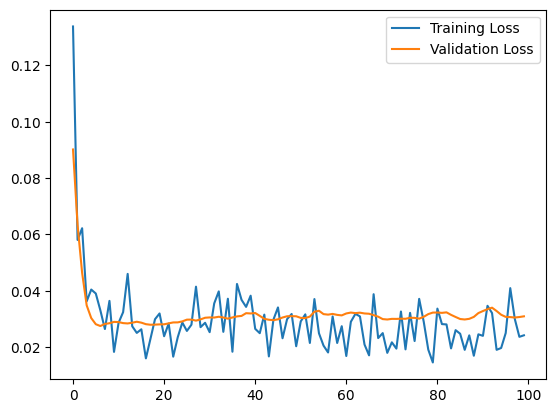

In [39]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()